In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path


In [3]:
# ── Copy images from Drive to Colab local disk (50x faster I/O) ─────────────
import shutil

LOCAL_IMG_DIR = Path('/content/Png')
LOCAL_IMG_DIR.mkdir(exist_ok=True)

if not any(LOCAL_IMG_DIR.iterdir()):  # skip if already copied
    print("Copying images from Drive to local disk (5-10 min, one-time)...")
    shutil.copytree(str(Path('/content/drive/MyDrive/Png')), str(LOCAL_IMG_DIR), dirs_exist_ok=True)
    print(f"Done! {len(list(LOCAL_IMG_DIR.glob('*.png')))} images copied.")
else:
    print(f"Already copied: {len(list(LOCAL_IMG_DIR.glob('*.png')))} images found locally.")


Copying images from Drive to local disk (5-10 min, one-time)...
Done! 7470 images copied.


In [5]:
!pip install iterative-stratification

In [6]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import ViTModel
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [19]:
# ── Paths ────────────────────────────────────────────────────────────────────
IMAGE_DIR = Path('/content/drive/MyDrive/Png')
CSV_PATH  = Path('/content/drive/MyDrive/dataset_labeled.csv')

# ── Label columns ────────────────────────────────────────────────────────────
LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule',
    'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation',
    'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal'
]
NUM_CLASSES = len(LABEL_COLS)

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE      = 224    # ViT expects 224×224
BATCH_SIZE    = 16
NUM_EPOCHS    = 20
LR            = 5e-5   # head LR; backbone gets LR * 0.1 after unfreeze
WEIGHT_DECAY  = 1e-4
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
WARMUP_EPOCHS = 3      # linear warmup before cosine decay

print(f'Number of classes: {NUM_CLASSES}')
print(f'Labels: {LABEL_COLS}')

Number of classes: 21
Labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule', 'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation', 'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal']


In [8]:
df = pd.read_csv(CSV_PATH)
print(f'Total rows: {len(df)}')
print(df[LABEL_COLS].sum().sort_values(ascending=False))

Total rows: 7470
Normal                4166
Calcinosis            1026
Opacity                996
Granuloma              814
Atelectasis            731
Cardiomegaly           662
Effusion               353
Emphysema              238
Nodule                 238
Atherosclerosis        234
Edema                  207
Fracture               193
Scoliosis              179
Infiltration           176
Pneumonia              171
Pleural_Thickening     110
Hernia                  96
Fibrosis                59
Pneumothorax            54
Consolidation           53
Mass                    41
dtype: int64


In [9]:
# Verify images exist and build clean image paths
df['img_path'] = df['image_id'].apply(lambda x: str(IMAGE_DIR / x))

# Drop rows where image file is missing
missing = df[~df['img_path'].apply(os.path.exists)]
print(f'Missing images: {len(missing)}')
df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Rows after dropping missing: {len(df)}')

Missing images: 0
Rows after dropping missing: 7470


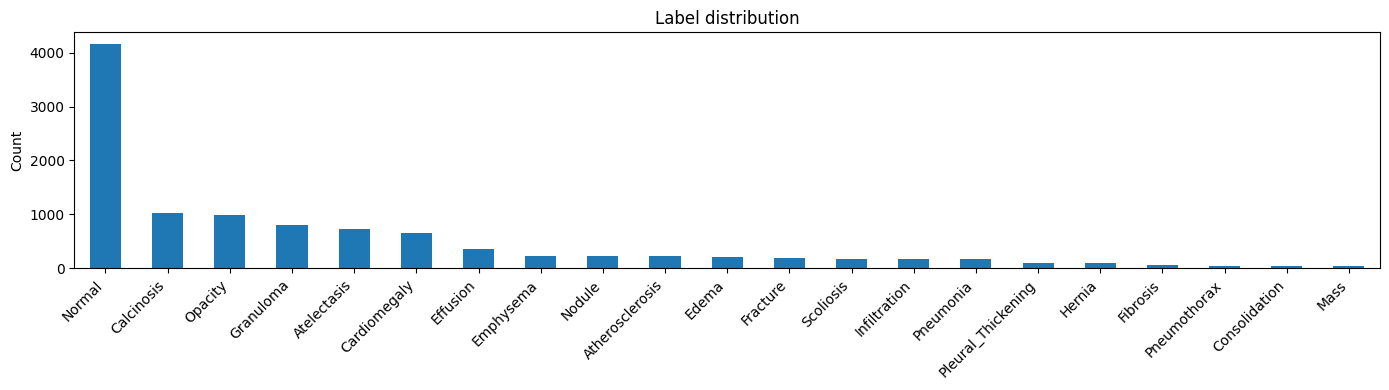

In [10]:
# Label distribution bar chart
counts = df[LABEL_COLS].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 4))
counts.plot(kind='bar')
plt.title('Label distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Multi-label stratified split — preserves per-class ratios across all 21 labels
# Unlike idxmax stratification, this accounts for every positive label per sample

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=(VAL_SPLIT + TEST_SPLIT), random_state=42
)
train_idx, temp_idx = next(msss.split(df, df[LABEL_COLS]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT), random_state=42
)
val_idx, test_idx = next(msss2.split(temp_df, temp_df[LABEL_COLS]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

# Verify class distribution is preserved
print('\nClass proportions (train vs val):')
for col in LABEL_COLS:
    tr = train_df[col].mean()
    vl = val_df[col].mean()
    print(f'  {col:<22} train={tr:.3f}  val={vl:.3f}')

Train: 5232  Val: 1109  Test: 1129

Class proportions (train vs val):
  Atelectasis            train=0.098  val=0.099
  Cardiomegaly           train=0.088  val=0.090
  Effusion               train=0.047  val=0.048
  Pneumonia              train=0.023  val=0.023
  Pneumothorax           train=0.007  val=0.007
  Edema                  train=0.028  val=0.028
  Emphysema              train=0.032  val=0.032
  Fibrosis               train=0.008  val=0.008
  Infiltration           train=0.024  val=0.024
  Mass                   train=0.006  val=0.005
  Nodule                 train=0.032  val=0.032
  Hernia                 train=0.013  val=0.014
  Fracture               train=0.026  val=0.026
  Pleural_Thickening     train=0.015  val=0.014
  Opacity                train=0.133  val=0.135
  Consolidation          train=0.007  val=0.007
  Granuloma              train=0.109  val=0.110
  Calcinosis             train=0.137  val=0.139
  Scoliosis              train=0.024  val=0.024
  Atherosclerosis 

In [24]:
# ViT models expect normalization with mean=0.5, std=0.5 (not ImageNet stats)
VIT_MEAN = [0.5, 0.5, 0.5]
VIT_STD  = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])


class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df         = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(row[self.label_cols].values.astype(float),
                              dtype=torch.float32)
        return image, labels


train_dataset = ChestXRayDataset(train_df, LABEL_COLS, train_transform)
val_dataset   = ChestXRayDataset(val_df,   LABEL_COLS, val_transform)
test_dataset  = ChestXRayDataset(test_df,  LABEL_COLS, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 327, val: 70, test: 71


In [25]:
class ViTChestClassifier(nn.Module):
    """
    ViT backbone from codewithdark/vit-chest-xray (pretrained on chest X-rays),
    with a new multi-label classification head for our 21 conditions.
    """
    def __init__(self, num_classes: int):
        super().__init__()
        self.vit = ViTModel.from_pretrained('codewithdark/vit-chest-xray')
        hidden_size = self.vit.config.hidden_size  # 768 for ViT-base

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_output = outputs.last_hidden_state[:, 0]  # [CLS] token
        return self.classifier(cls_output)


model = ViTChestClassifier(NUM_CLASSES).to(DEVICE)

# ── Phase 1: freeze backbone, train only the classifier head ─────────────────
for param in model.vit.parameters():
    param.requires_grad = False

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}  (head only)')
print(f'Frozen params:    {total_params - trainable_params:,}  (ViT backbone)')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: codewithdark/vit-chest-xray
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     86,793,749
Trainable params: 404,501  (head only)
Frozen params:    86,389,248  (ViT backbone)


In [26]:
# Positive frequency per class → weight = neg_freq / pos_freq
pos_counts = train_df[LABEL_COLS].sum().values
neg_counts = len(train_df) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer — only unfrozen (head) parameters at this stage
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

# ── Scheduled LR: linear warmup → cosine decay ───────────────────────────────
# Warmup: LR goes from LR*0.1 → LR over WARMUP_EPOCHS epochs
# Cosine: LR decays from LR → ~0 over the remaining epochs
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

print('Positive weights (first 5):', pos_weight[:5].cpu().numpy())
print(f'LR schedule: warmup {WARMUP_EPOCHS} epochs → cosine decay to 1e-6')

Positive weights (first 5): [  9.21875   10.300216  20.182186  42.6      136.6842  ]
LR schedule: warmup 3 epochs → cosine decay to 1e-6


In [27]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images, labels in tqdm(loader, leave=False, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []
    for images, labels in tqdm(loader, leave=False, desc='Eval'):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    # Per-class AUC (skip classes with only one label value present)
    auc_scores = []
    for i in range(all_labels.shape[1]):
        if len(np.unique(all_labels[:, i])) > 1:
            auc_scores.append(roc_auc_score(all_labels[:, i], all_probs[:, i]))
        else:
            auc_scores.append(float('nan'))
    mean_auc = np.nanmean(auc_scores)

    return total_loss / len(loader.dataset), mean_auc, auc_scores

In [28]:
history    = {"train_loss": [], "val_loss": [], "val_auc": [], "lr": []}
best_auc   = 0.0
CKPT_PATH  = '/content/drive/MyDrive/best_vit_chest.pth'
PATIENCE   = 5
no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Phase 2: unfreeze backbone after warmup ───────────────────────────────
    if epoch == WARMUP_EPOCHS + 1:
        for param in model.vit.parameters():
            param.requires_grad = True
        optimizer.add_param_group({
            'params': model.vit.parameters(),
            'lr': LR * 0.1,
            'weight_decay': WEIGHT_DECAY
        })
        # Keep cosine scheduler in sync with the new param group
        cosine_scheduler.base_lrs.append(LR * 0.1)
        print(f'  [Epoch {epoch}] Backbone unfrozen — backbone lr={LR * 0.1:.1e}')

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_auc, _ = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Mean AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        no_improve = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  New best AUC {best_auc:.4f} — checkpoint saved")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"Training complete. Best Val AUC: {best_auc:.4f}")


Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 01/20 | LR: 5.00e-06 | Train Loss: 1.3093 | Val Loss: 1.2998 | Val Mean AUC: 0.5354
  New best AUC 0.5354 — checkpoint saved


Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 19/20 | LR: 2.65e-06 | Train Loss: 0.7381 | Val Loss: 1.1094 | Val Mean AUC: 0.7865
  New best AUC 0.7865 — checkpoint saved


Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 20/20 | LR: 1.42e-06 | Train Loss: 0.7330 | Val Loss: 1.1042 | Val Mean AUC: 0.7867
  New best AUC 0.7867 — checkpoint saved
Training complete. Best Val AUC: 0.7867


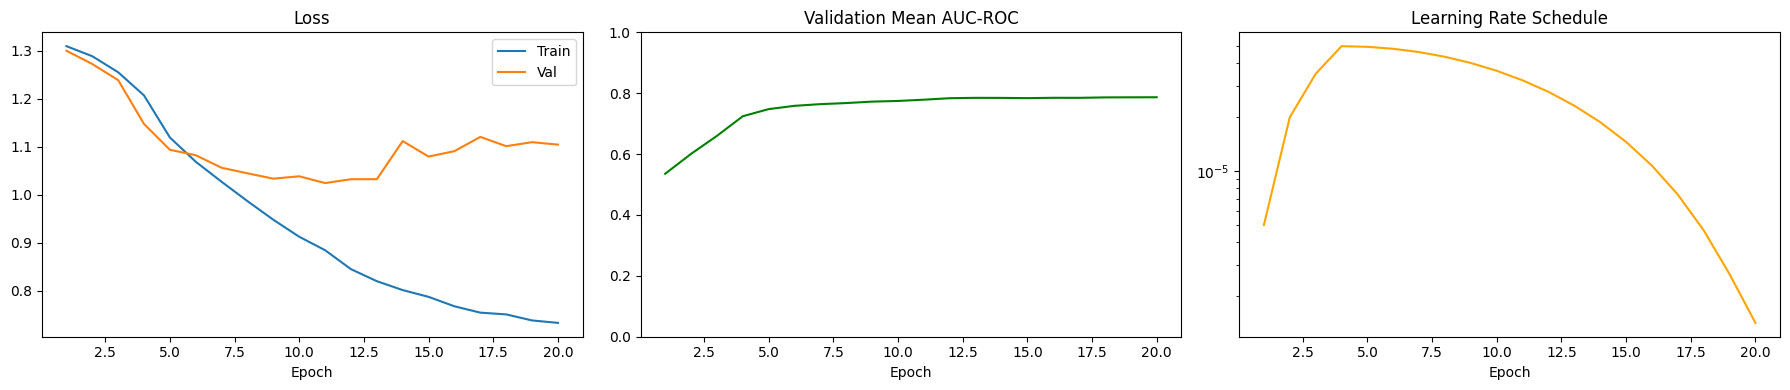

In [29]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["val_auc"], color="green")
axes[1].set_title("Validation Mean AUC-ROC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)

axes[2].plot(epochs, history["lr"], color="orange")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

In [30]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

test_loss, test_auc, per_class_auc = evaluate(model, test_loader, criterion, DEVICE)
print(f'Test Loss: {test_loss:.4f}  |  Test Mean AUC: {test_auc:.4f}\n')

# Per-class AUC table
auc_df = pd.DataFrame({'Condition': LABEL_COLS, 'AUC-ROC': per_class_auc})
auc_df = auc_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(auc_df.to_string(index=False))

Eval:   0%|          | 0/71 [00:00<?, ?it/s]

Test Loss: 1.2744  |  Test Mean AUC: 0.7359

         Condition  AUC-ROC
          Fibrosis 0.935020
         Emphysema 0.880700
     Consolidation 0.872324
          Effusion 0.870011
            Hernia 0.845932
      Cardiomegaly 0.831362
             Edema 0.792790
           Opacity 0.772593
   Atherosclerosis 0.766675
       Atelectasis 0.734754
         Pneumonia 0.733071
      Pneumothorax 0.722235
            Normal 0.713460
      Infiltration 0.699003
         Scoliosis 0.645023
              Mass 0.635649
        Calcinosis 0.629604
          Fracture 0.599718
            Nodule 0.597388
Pleural_Thickening 0.589822
         Granuloma 0.587641
